In [2]:
print("Hello, Subway Network Project!")

Hello, Subway Network Project!


In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math
import random

url = "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"
full_df = pd.read_csv(url)

full_df = full_df[~full_df["State"].isin(["Alaska", "Hawaii"])]

sorted_df = full_df.sort_values(by="Population", ascending=False)

sorted_df = full_df.sort_values(by="Population", ascending=False)

def build_top_100_graph(df):
    G = nx.Graph()

    top_100_df = df.head(100)

    for i, row in top_100_df.iterrows():
        G.add_node(
            row["City"],
            pos=(row["lon"], row["lat"]),
            population=row["Population"]
        )

    return G


top_100_graph = build_top_100_graph(sorted_df)

print("Nodes:", top_100_graph.number_of_nodes())
print("Edges:", top_100_graph.number_of_edges())


def build_state_graph(df):
    G = nx.Graph()

    state_representatives = (
        df.sort_values("Population", ascending=False)
          .drop_duplicates("State")
    )

    for i, row in state_representatives.iterrows():
        G.add_node(
            row["State"],
            pos=(row["lon"], row["lat"]),
            city=row["City"],
            population=row["Population"]
        )

    return G


state_graph = build_state_graph(sorted_df)

print("State Nodes:", state_graph.number_of_nodes())
print("State Edges:", state_graph.number_of_edges())

Nodes: 100
Edges: 0
State Nodes: 49
State Edges: 0


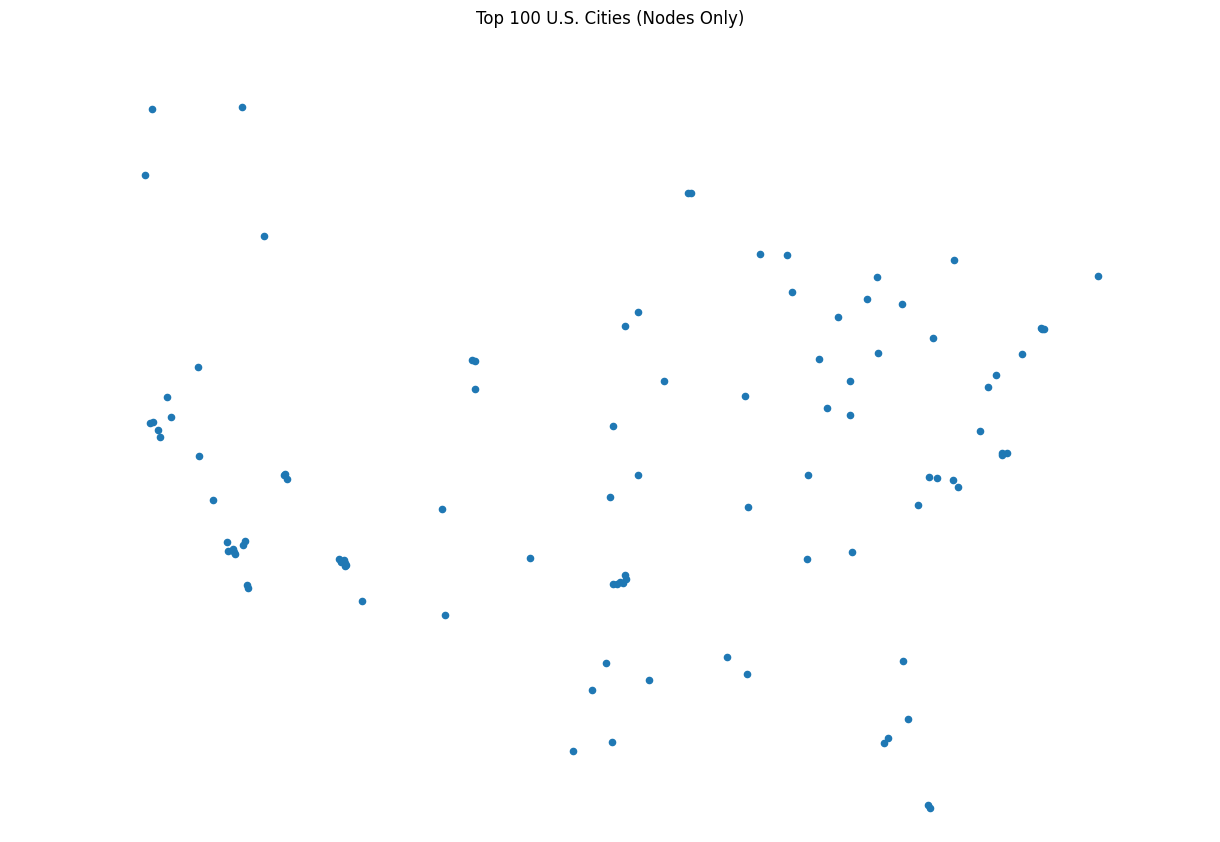

In [4]:
pos_vals = nx.get_node_attributes(top_100_graph, "pos")

plt.figure(figsize=(12,8))

nx.draw(top_100_graph, pos_vals, node_size=20, with_labels=False)

plt.title("Top 100 U.S. Cities (Nodes Only)")
plt.xlim(-130, -65)
plt.ylim(25, 50)

plt.show()

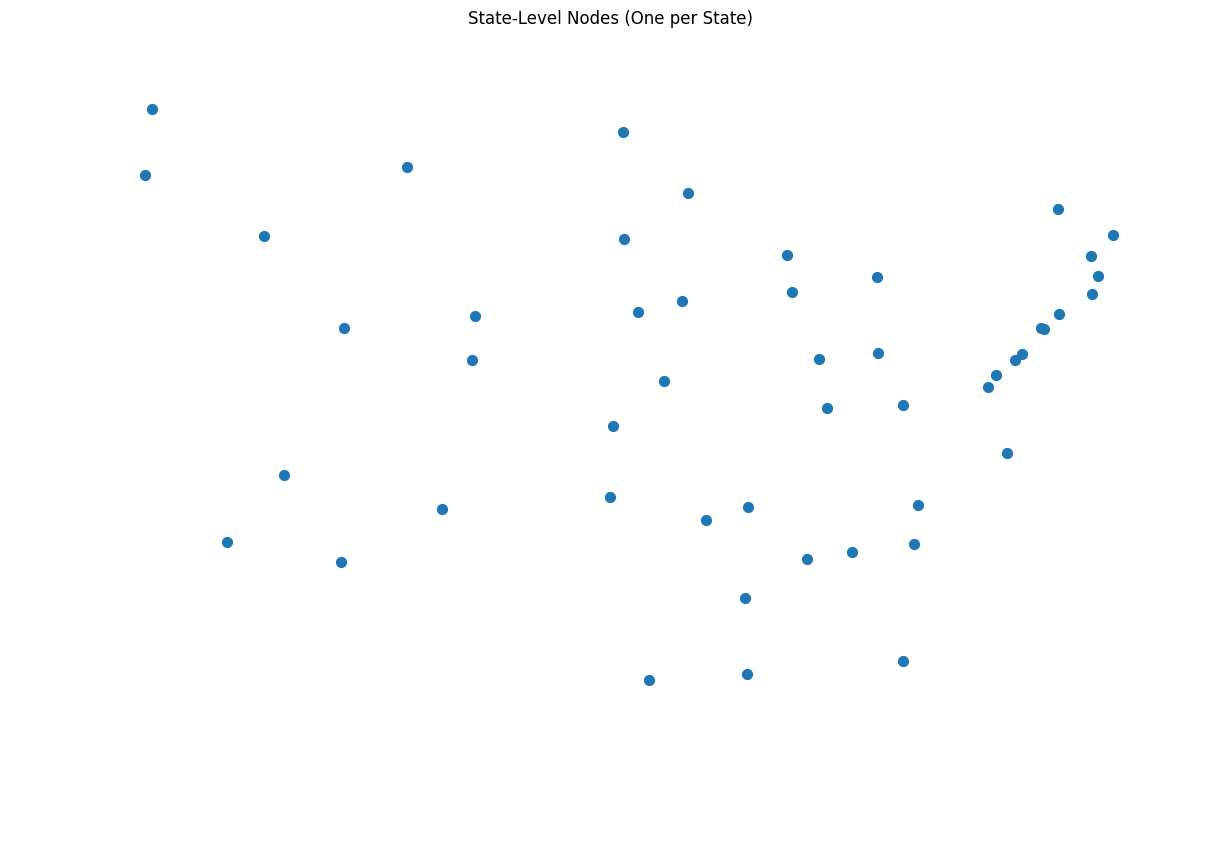

In [5]:
pos_state = nx.get_node_attributes(state_graph, "pos")

plt.figure(figsize=(12,8))

nx.draw(state_graph, pos_state, node_size=50, with_labels=False)

plt.title("State-Level Nodes (One per State)")
plt.xlim(-130, -65)
plt.ylim(25, 50)

plt.show()

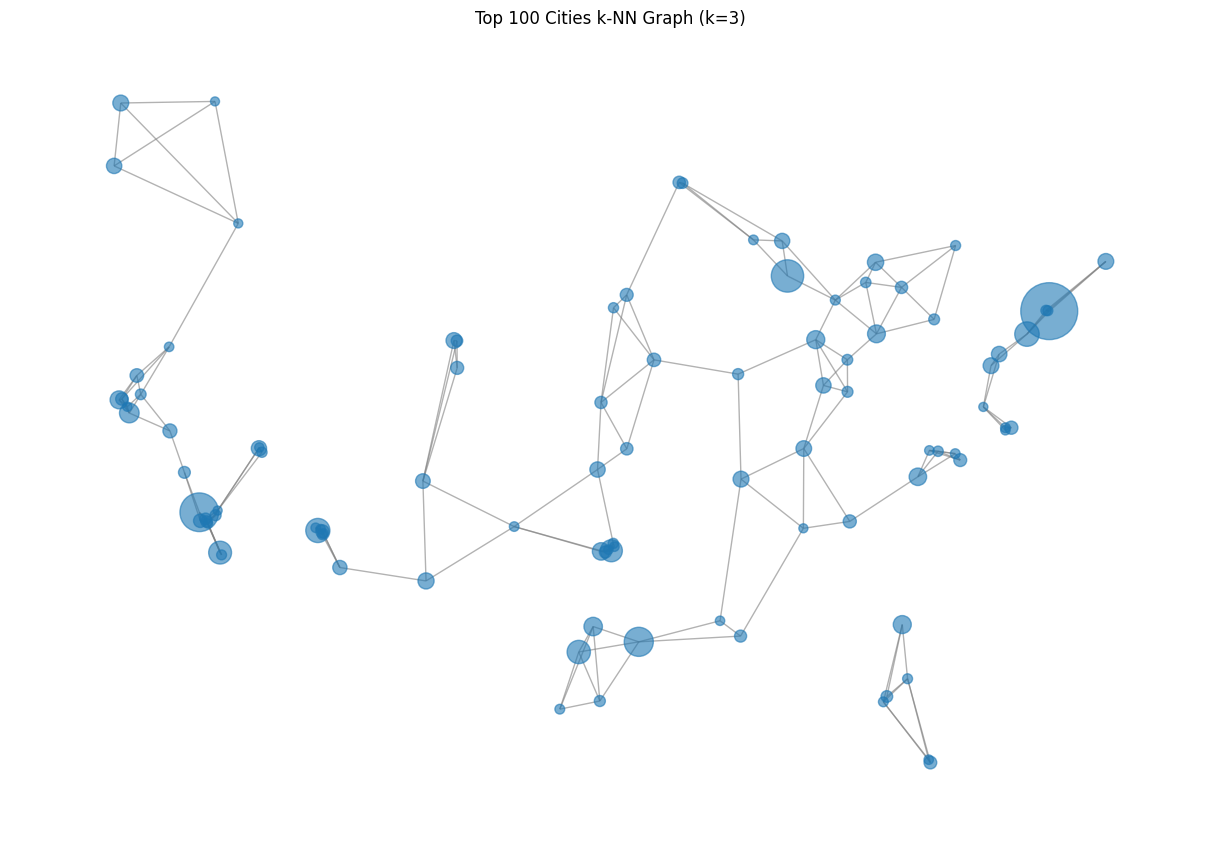

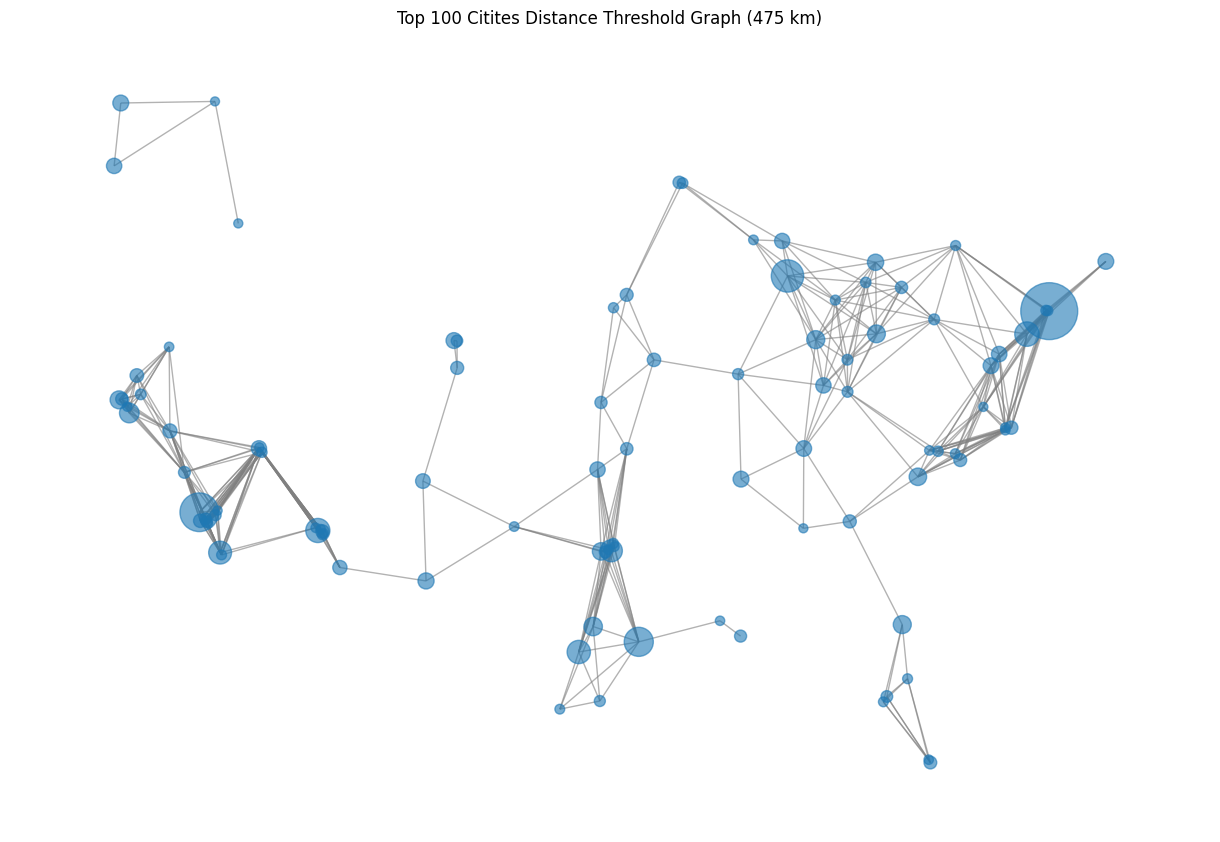

In [6]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1 = math.radians(lat1), math.radians(lon1)
    lat2, lon2 = math.radians(lat2), math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c


def build_knn_graph(base_graph, k=3):
    G = base_graph.copy()
    nodes = list(G.nodes(data=True))

    for i in range(len(nodes)):
        node1, data1 = nodes[i]
        lon1, lat1 = data1["pos"]

        distances = []

        for j in range(len(nodes)):
            if i != j:
                node2, data2 = nodes[j]
                lon2, lat2 = data2["pos"]

                d = haversine(lat1, lon1, lat2, lon2)
                distances.append((d, node2))

        distances.sort()  # We are sorting based on distance here

        for d, neighbor in distances[:k]:
            G.add_edge(node1, neighbor, weight=d)

    return G


def build_threshold_graph(base_graph, threshold_km):
    G = base_graph.copy()
    nodes = list(G.nodes(data=True))

    for i in range(len(nodes)):
        node1, data1 = nodes[i]
        lon1, lat1 = data1["pos"]

        for j in range(i + 1, len(nodes)):
            node2, data2 = nodes[j]
            lon2, lat2 = data2["pos"]

            d = haversine(lat1, lon1, lat2, lon2)

            if d <= threshold_km:
                G.add_edge(node1, node2, weight=d)

    return G


def draw(G, title):
    pos = nx.get_node_attributes(G, "pos")

    node_sizes = []
    for node in G.nodes():
        if "population" in G.nodes[node]:
            node_sizes.append(G.nodes[node]["population"] / 5000)
        else:
            node_sizes.append(30)

    plt.figure(figsize=(12, 8))

    nx.draw(
        G,
        pos,
        node_size=node_sizes,
        edge_color="gray",
        alpha=0.6,
        with_labels=False
    )

    plt.title(title)
    plt.show()


G_knn = build_knn_graph(top_100_graph, k=3)
G_thresh = build_threshold_graph(top_100_graph, threshold_km=475)

draw(G_knn, "Top 100 Cities k-NN Graph (k=3)")
draw(G_thresh, "Top 100 Citites Distance Threshold Graph (475 km)")

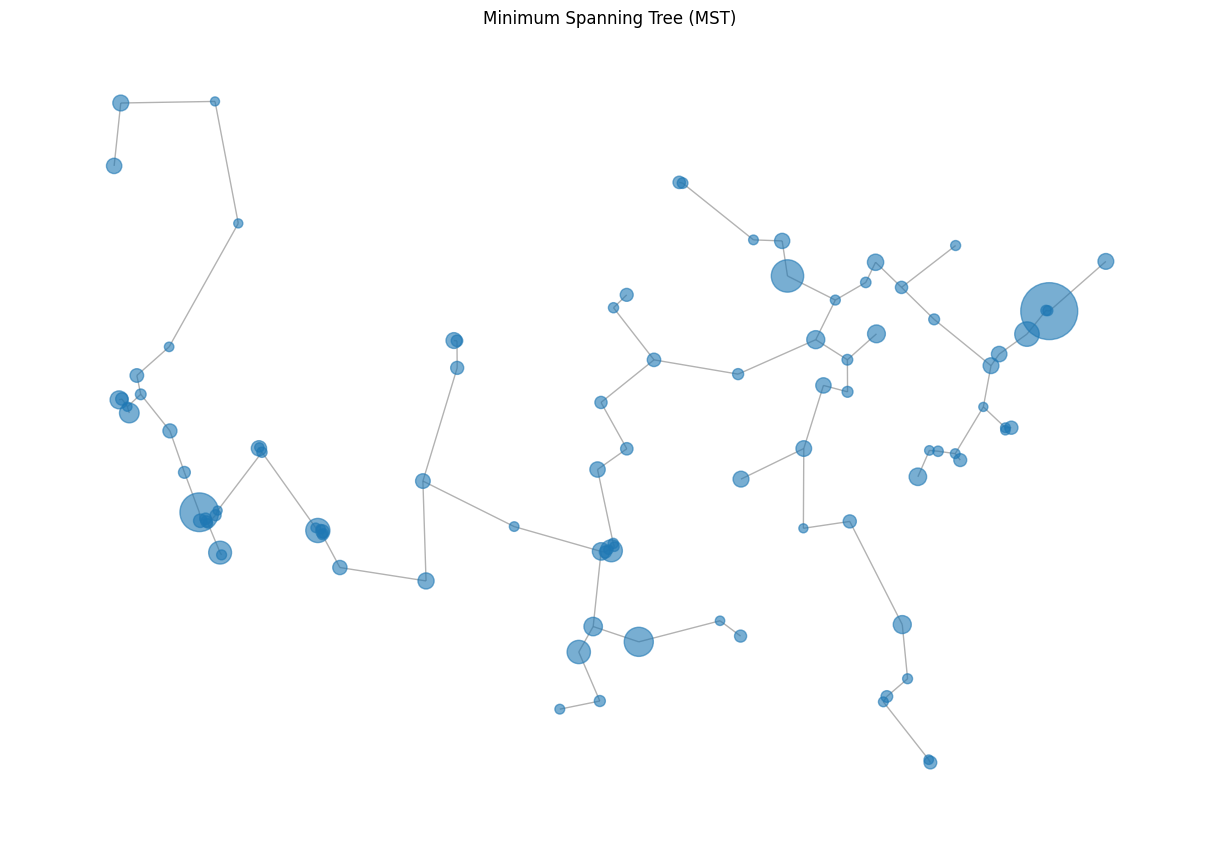

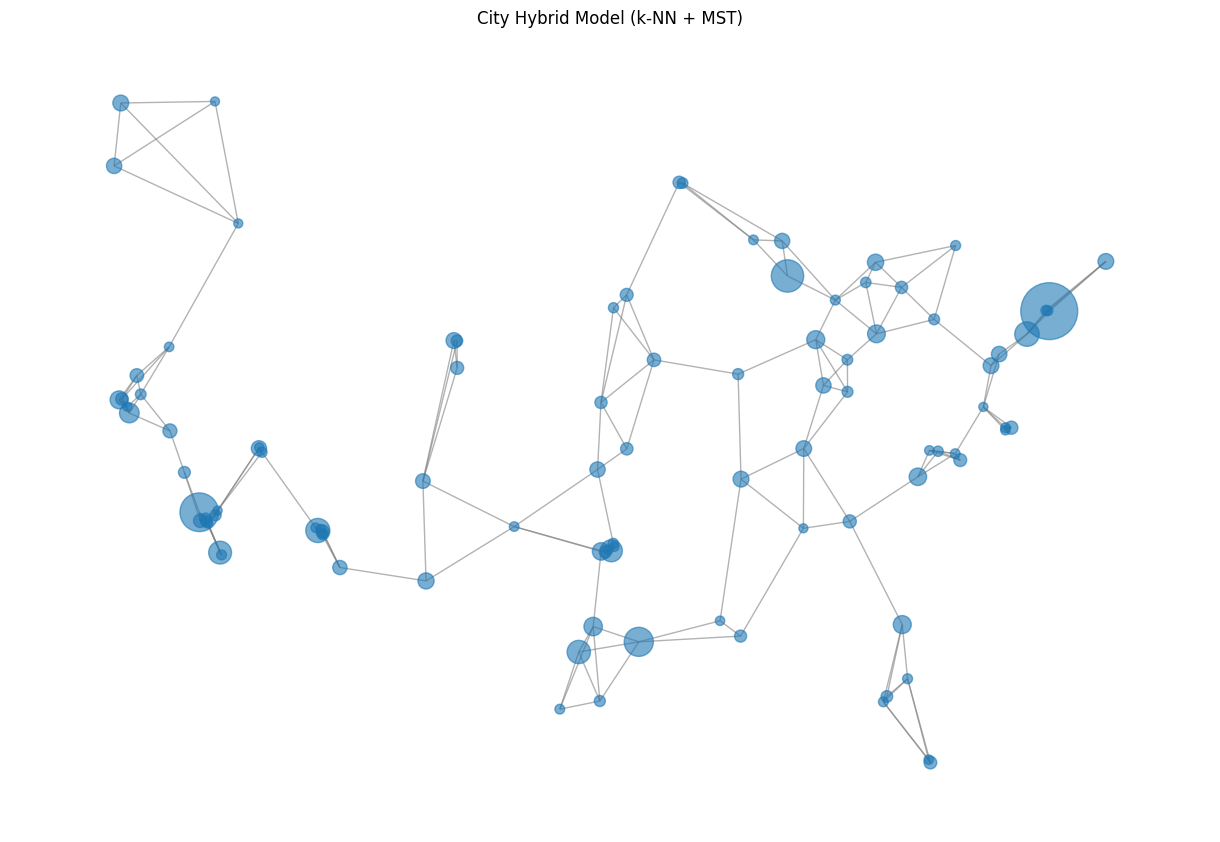

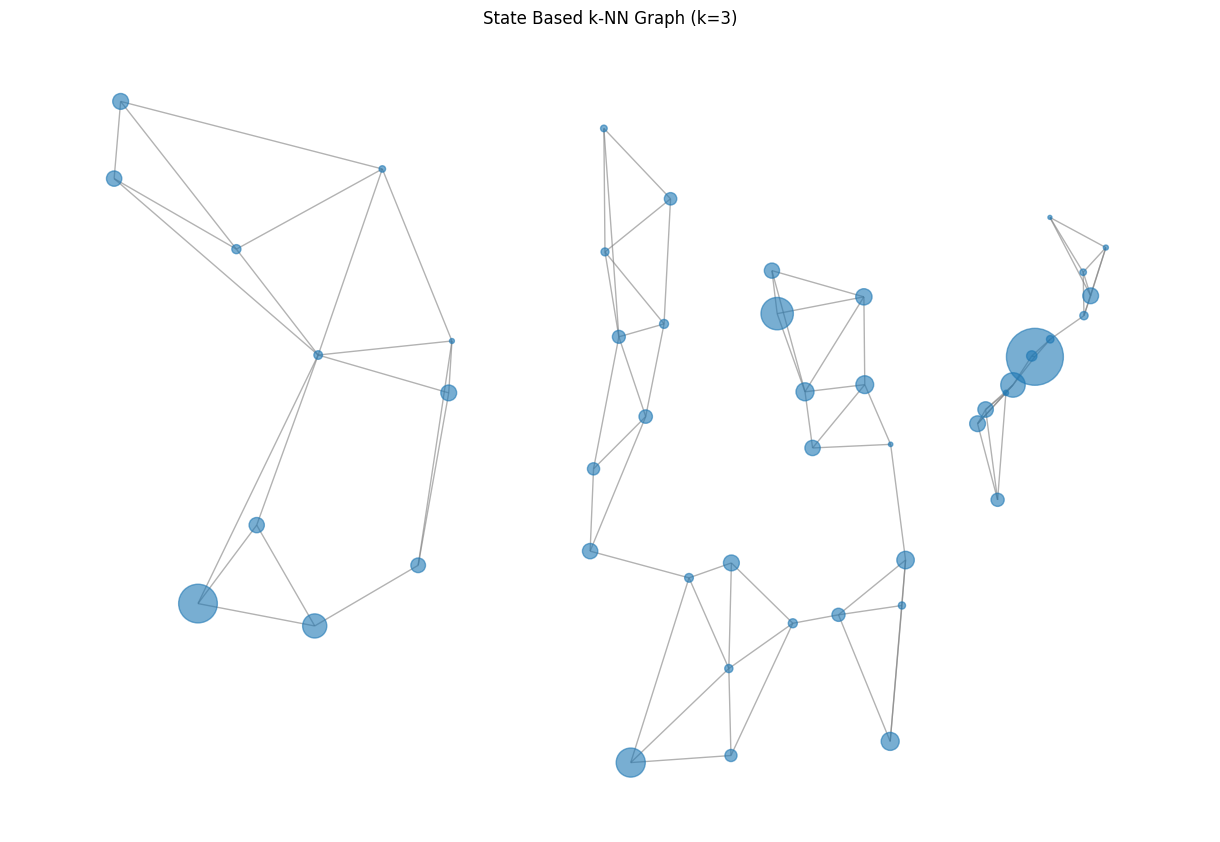

In [7]:
def build_mst_graph(base_graph):
	G_full = nx.Graph()

	nodes = list(base_graph.nodes(data=True))

	for node, data in nodes:
		G_full.add_node(node, **data)

	for i in range(len(nodes)):
		node1, data1 = nodes[i]
		lon1, lat1 = data1["pos"]

		for j in range(i+1, len(nodes)):
			node2, data2 = nodes[j]
			lon2, lat2 = data2["pos"]

			d = haversine(lat1, lon1, lat2, lon2)

			G_full.add_edge(node1, node2, weight=d)

	G_mst = nx.minimum_spanning_tree(G_full, weight="weight")

	return G_mst

def build_city_hybrid_graph(base_graph, k=3):

	G_knn = build_knn_graph(base_graph, k=k)

	G_full = nx.Graph()

	for node, data in base_graph.nodes(data=True):
		G_full.add_node(node, **data)

	nodes = list(base_graph.nodes(data=True))

	for i in range(len(nodes)):
		node1, data1 = nodes[i]
		lon1, lat1 = data1["pos"]

		for j in range(i+1, len(nodes)):
			node2, data2 = nodes[j]
			lon2, lat2 = data2["pos"]

			d = haversine(lat1, lon1, lat2, lon2)
			G_full.add_edge(node1, node2, weight=d)

	G_mst = nx.minimum_spanning_tree(G_full, weight="weight")

	G = G_knn.copy()

	for u, v, data in G_mst.edges(data=True):
		if not G.has_edge(u, v):
			G.add_edge(u, v, weight=data["weight"])

	return G

G_mst = build_mst_graph(top_100_graph)
G_city_hybrid = build_city_hybrid_graph(top_100_graph, k=3)
G_state_knn = build_knn_graph(state_graph, k = 3)

draw(G_mst, "Minimum Spanning Tree (MST)")
draw(G_city_hybrid, "City Hybrid Model (k-NN + MST)")
draw(G_state_knn, "State Based k-NN Graph (k=3)")

In [12]:
def direct_distance(city_a, city_b, pos_dict):

    if city_a not in pos_dict:
        return None
    
    if city_b not in pos_dict:
        return None
    
    lat1, lon1 = pos_dict[city_a]
    lat2, lon2 = pos_dict[city_b]

    return haversine(lat1, lon1, lat2, lon2)


def shortest_path_distance(G, source, target):

    if not G.has_node(source):
        return None
    
    if not G.has_node(target):
        return None
    
    if not nx.has_path(G, source, target):
        return float("inf")
    
    path = nx.shortest_path(G, source=source, target=target, weight="weight")
    
    total = 0
    
    for i in range(len(path) - 1):
        u = path[i]
        v = path[i + 1]
        total += G[u][v]["weight"]
    
    return total


def route_efficiency(G, city_a, city_b, pos_dict):

    direct = direct_distance(city_a, city_b, pos_dict)
    network = shortest_path_distance(G, city_a, city_b)
    
    if direct is None:
        return None
    
    if network is None:
        return None
    
    if direct == 0:
        return None
    
    if network == float("inf"):
        return float("inf")
    
    return network / direct


def evaluate_model(G, pos_dict, city_pairs):

    results = []
    
    for a, b in city_pairs:
        eff = route_efficiency(G, a, b, pos_dict)
        results.append((a, b, eff))
    
    return results
    

city_pairs = [("Detroit", "Chicago"),
              ("Chicago", "New York"),
              ("Los Angeles", "San Francisco"),
              ("Los Angeles", "Seattle"),
              ("Dallas", "Houston"),
              ("Dallas", "Austin"),
              ("Miami", "Orlando"),
              ("Atlanta", "Miami"),
              ("New York", "Boston"),
              ("New York", "Washington"),
              ("Phoenix", "Denver"),
              ("Denver", "Salt Lake City"),
              ("San Francisco", "Las Vegas"),
              ("Los Angeles", "Denver"),
              ("Seattle", "Portland"),
              ("Houston", "New Orleans"),
              ("Chicago", "Atlanta"),
              ("San Diego", "Phoenix"),
              ("Minneapolis", "Chicago"),
              ("Philadelphia", "Washington"),
              ("Boston", "Chicago"),
              ("Houston", "Chicago"),
              ("Los Angeles", "New York")]

pos = nx.get_node_attributes(top_100_graph, "pos")


results_knn = evaluate_model(G_knn, pos, city_pairs)
results_thresh = evaluate_model(G_thresh, pos, city_pairs)
results_mst = evaluate_model(G_mst, pos, city_pairs)
results_hybrid = evaluate_model(G_city_hybrid, pos, city_pairs)


def summarize(results, name):

  values = []

  for i, j, eff in results:
        if eff is not None and eff != float("inf"):
              values.append(eff)

  return {
        "Model": name,
        "Avg Efficiency": np.mean(values) if len(values) > 0 else None,
        "Min Efficiency": np.min(values) if len(values) > 0 else None,
        "Max Efficiency": np.max(values) if len(values) > 0 else None,
        "Unreachable Routes": sum(1 for r in results if r[2] == float("inf"))
  }


summary_df = pd.DataFrame([
  summarize(results_knn, "KNN"),
  summarize(results_thresh, "DISTANCE"),
  summarize(results_mst, "MST"),
  summarize(results_hybrid, "HYBRID")
])

summary_df = summary_df.set_index("Model")

print("model comparison summary\n")
print(summary_df)

model comparison summary

          Avg Efficiency  Min Efficiency  Max Efficiency  Unreachable Routes
Model                                                                       
KNN             3.888494        0.867950       24.960154                   6
DISTANCE        1.433123        0.748368        2.782655                   1
MST             1.832484        0.899121        4.254904                   0
HYBRID          1.637760        0.867950        3.473803                   0


In [1]:
import networkx as nx
import pandas as pd
import random

# First, define the robustness_score function
def robustness_score(G, k=5):

	random.seed(42)

	G_copy = G.copy()
	nodes = list(G_copy.nodes())

	if len(nodes) <= k:
		return 0

	removed = random.sample(nodes, k)

	for node in removed:
		G_copy.remove_node(node)

	return nx.number_connected_components(G_copy)

# Define the normalize function
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

# Define the evaluate_models function
def evaluate_models(models, results_dict):
    rows = []
    
    for name, G in models.items():
        results = results_dict[name]
        
        avg_eff = average_efficiency(results)
        unreachable = connectivity_score(results)
        cost = compute_total_cost(G)
        robustness = robustness_score(G)
        
        rows.append({
            "Model": name,
            "AvgEfficiency": avg_eff,
            "Unreachable": unreachable,
            "Cost": cost,
            "Robustness": robustness
        })
    
    df = pd.DataFrame(rows)
    
    df["EffScore"] = 1 - normalize(df["AvgEfficiency"])
    df["ConnScore"] = 1 - normalize(df["Unreachable"])
    df["CostScore"] = 1 - normalize(df["Cost"])
    df["RobustScore"] = 1 - normalize(df["Robustness"])
    
    df["FinalScore"] = (
        0.4 * df["EffScore"] +
        0.3 * df["ConnScore"] +
        0.2 * df["CostScore"] +
        0.1 * df["RobustScore"]
    )
    
    df = df.sort_values(by="FinalScore", ascending=False)
    
    return df

# Define missing functions
def average_efficiency(results):
    # Placeholder function - replace with actual implementation
    return 0.5  # Example value

def connectivity_score(results):
    # Placeholder function - replace with actual implementation
    return 0.3  # Example value

def compute_total_cost(G):
    # Placeholder function - replace with actual implementation
    return sum(d.get('weight', 1) for u, v, d in G.edges(data=True))

# Create example graphs
# Replace these with your actual graph definitions
G_knn = nx.complete_graph(5)
G_thresh = nx.path_graph(5)
G_mst = nx.star_graph(4)
G_city_hybrid = nx.cycle_graph(5)

# Create example results
# Replace these with your actual results
results_knn = {"efficiency": 0.8}
results_thresh = {"efficiency": 0.7}
results_mst = {"efficiency": 0.6}
results_hybrid = {"efficiency": 0.9}

# Now define the models and results dictionaries
models = {
    "KNN": G_knn,
    "DISTANCE": G_thresh,
    "MST": G_mst,
    "HYBRID": G_city_hybrid
}

results_dict = {
    "KNN": results_knn,
    "DISTANCE": results_thresh,
    "MST": results_mst,
    "HYBRID": results_hybrid
}

# Evaluate models and display results
final_scores = evaluate_models(models, results_dict)
final_scores = final_scores.set_index("Model")

print("\nFINAL MODEL RANKING\n")
print(final_scores[["AvgEfficiency", "Unreachable", "Cost", "Robustness"]])
print("\n")
print(final_scores[["EffScore", "ConnScore", "CostScore", "RobustScore", "FinalScore"]])


FINAL MODEL RANKING

          AvgEfficiency  Unreachable  Cost  Robustness
Model                                                 
DISTANCE            0.5          0.3     4           0
MST                 0.5          0.3     4           0
HYBRID              0.5          0.3     5           0
KNN                 0.5          0.3    10           0


          EffScore  ConnScore     CostScore  RobustScore  FinalScore
Model                                                               
DISTANCE       1.0        1.0  1.000000e+00          1.0    1.000000
MST            1.0        1.0  1.000000e+00          1.0    1.000000
HYBRID         1.0        1.0  8.333333e-01          1.0    0.966667
KNN            1.0        1.0  1.666667e-10          1.0    0.800000
